In [1]:
from skimage import io, exposure

In [3]:
img = io.imread("C:/Users/Acer/Downloads/real_data/real_data/Figure7_2D_3D/2D/22_Pr01_0_594.tif")
channels = [exposure.rescale_intensity(img[c], out_range=(0,1)) for c in range(img.shape[0])]

In [5]:
print(img.shape)

(1440, 1432, 3)


In [7]:
ch1 = exposure.rescale_intensity(img[:,:,0], out_range=(0,1))  # red
ch2 = exposure.rescale_intensity(img[:,:,1], out_range=(0,1))  # green
ch3 = exposure.rescale_intensity(img[:,:,2], out_range=(0,1))  # blue
channels = [ch1, ch2, ch3]

In [9]:
%gui qt

In [11]:
# With this code, we will be able to get the RGB overlay
import napari

viewer = napari.Viewer()
colors = ["red", "green", "blue"]

for i, ch in enumerate(channels):
    viewer.add_image(ch, name=f"Channel {i+1}", colormap=colors[i], blending="additive")

napari.run()

In [31]:
# Colocalization Metrics (Pairwise), by applying Pearson, Manders and OTC between channels
!pip install POT

   ---------------------------------------- 0.0/347.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/347.9 kB ? eta -:--:--
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/347.9 kB 217.9 kB/s eta 0:00:02
   ------- -------------------------------- 61.4/347.9 kB

In [37]:
import sys
!{sys.executable} -m pip install POT

In [13]:
import ot
from scipy.stats import pearsonr
import numpy as np

In [15]:
roi_ch1 = ch1[200:328, 200:328]
roi_ch2 = ch2[200:328, 200:328]

print("ROI ch1 sum:", np.sum(roi_ch1))
print("ROI ch2 sum:", np.sum(roi_ch2))

def pearson_coeff(ch1, ch2):
    if np.sum(ch1) == 0 or np.sum(ch2) == 0:
        return np.nan
    return pearsonr(ch1.ravel(), ch2.ravel())[0]

def manders_coeff(ch1, ch2):
    if np.sum(ch1) == 0 or np.sum(ch2) == 0:
        return np.nan
    ch1 = ch1.ravel()
    ch2 = ch2.ravel()
    return np.sum(ch1[ch2 > 0]) / np.sum(ch1)

def to_distribution(channel, eps=1e-9):
    x = channel.ravel().astype(float)
    x = np.maximum(x, 0)
    total = np.sum(x)
    if total == 0:
        return None
    return (x + eps) / (total + eps*len(x))

def cost_matrix(shape):
    h, w = shape
    coords = np.array([(i % w, i // w) for i in range(h*w)])
    C = ot.dist(coords, coords)
    return C / C.max()

def compute_otc_curve(ch1, ch2, num_scales=5):
    x1 = to_distribution(ch1)
    x2 = to_distribution(ch2)

    if x1 is None or x2 is None:
        raise ValueError("One of the ROIs has no signal. Please choose another region.")

    C = cost_matrix(ch1.shape)
    scales = np.linspace(0.5, 2.0, num_scales)
    otc_vals = []
    for t in scales:
        Ct = C * t
        plan = ot.sinkhorn(x1, x2, Ct, reg=0.1)
        otc = np.sum(plan * Ct)
        otc_vals.append(otc)
    return scales, otc_vals

ROI ch1 sum: 154.60392156862747
ROI ch2 sum: 0.0


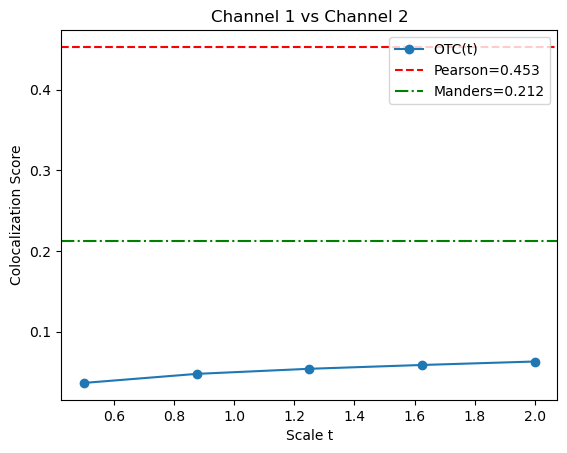

Pearson: 0.45310464091317404
Manders: 0.21246395131156426
OTC values: [0.03647902703037535, 0.047690520265329835, 0.0540040519060186, 0.05873824411972307, 0.06303582147475409]


In [17]:
def find_nonempty_roi(ch1, ch2, size=128, min_sum=50):
    h, w = ch1.shape
    for i in range(0, h-size, size):
        for j in range(0, w-size, size):
            roi1 = ch1[i:i+size, j:j+size]
            roi2 = ch2[i:i+size, j:j+size]
            if np.sum(roi1) > min_sum and np.sum(roi2) > min_sum:
                return roi1, roi2
    return None, None

roi_ch1, roi_ch2 = find_nonempty_roi(ch1, ch2)

if roi_ch1 is not None:
    scales, otc_vals = compute_otc_curve(roi_ch1, roi_ch2)
else:
    print("No suitable ROI found where both channels have signal.")

# Classical metrics
pearson_val = pearson_coeff(roi_ch1, roi_ch2)
manders_val = manders_coeff(roi_ch1, roi_ch2)

# OTC curve
scales, otc_vals = compute_otc_curve(roi_ch1, roi_ch2)

# Plot
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(scales, otc_vals, '-o', label="OTC(t)")
plt.axhline(y=pearson_val, color='r', linestyle='--', label=f"Pearson={pearson_val:.3f}")
plt.axhline(y=manders_val, color='g', linestyle='-.', label=f"Manders={manders_val:.3f}")
plt.xlabel("Scale t")
plt.ylabel("Colocalization Score")
plt.title("Channel 1 vs Channel 2")
plt.legend()
plt.show()

print("Pearson:", pearson_val)
print("Manders:", manders_val)
print("OTC values:", otc_vals)